# Hospital Readmission Prediction

**Domain:** Healthcare  
**Dataset:** Diabetes 130-US Hospitals 1999–2008 (UCI Machine Learning Repository)  
**Language:** Python  

---

## Business Problem

Hospital readmissions within 30 days of discharge are a key quality and cost metric in healthcare. Avoidable readmissions cost billions annually and are subject to financial penalties under the Hospital Readmissions Reduction Program (HRRP). Identifying high-risk patients at discharge enables targeted interventions — follow-up calls, care coordination, medication review — that reduce readmission rates and improve patient outcomes.

This project builds and evaluates a predictive model for 30-day readmission risk using structured clinical and administrative data from 130 US hospitals.

**Central question:**  
Which patients are most likely to be readmitted within 30 days, and what clinical factors are driving that risk?

---

## Notebook Structure

1. Setup and data loading  
2. Data cleaning and preprocessing  
3. Exploratory data analysis  
4. Baseline model — Logistic Regression  
5. Advanced models — Random Forest & Gradient Boosting  
6. Class imbalance handling — SMOTE  
7. Model evaluation — ROC-AUC, PR curve, calibration  
8. Explainability — Feature importance & SHAP values  
9. Business interpretation & deployment framing  

---

*industry_projects — Samantha McGarrigle*

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import missingno as msno
import shap

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Setup and Data Loading

We load the Diabetes 130-US Hospitals dataset, inspect its structure, and convert placeholder missing
values (`?`) into proper `NaN` values.

Each row represents a single inpatient encounter for a diabetic patient between 1999 and 2008.

In [5]:
data_path = "data/diabetic_data.csv"   # update path if needed

df = pd.read_csv(data_path)

df.shape, df.head()

((101766, 50),
    encounter_id  patient_nbr             race  gender      age weight  \
 0       2278392      8222157        Caucasian  Female   [0-10)      ?   
 1        149190     55629189        Caucasian  Female  [10-20)      ?   
 2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
 3        500364     82442376        Caucasian    Male  [30-40)      ?   
 4         16680     42519267        Caucasian    Male  [40-50)      ?   
 
    admission_type_id  discharge_disposition_id  admission_source_id  \
 0                  6                        25                    1   
 1                  1                         1                    7   
 2                  1                         1                    7   
 3                  1                         1                    7   
 4                  1                         1                    7   
 
    time_in_hospital payer_code         medical_specialty  num_lab_procedures  \
 0                 1    

### Inspect Data Structure and Missingness

We examine:

- Variable types  
- Basic descriptive statistics  
- Missingness patterns using `missingno`  

The dataset contains many categorical variables encoded as strings, including several with missing values represented as `?`.

In [6]:
df.info()
df.describe(include="all").T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


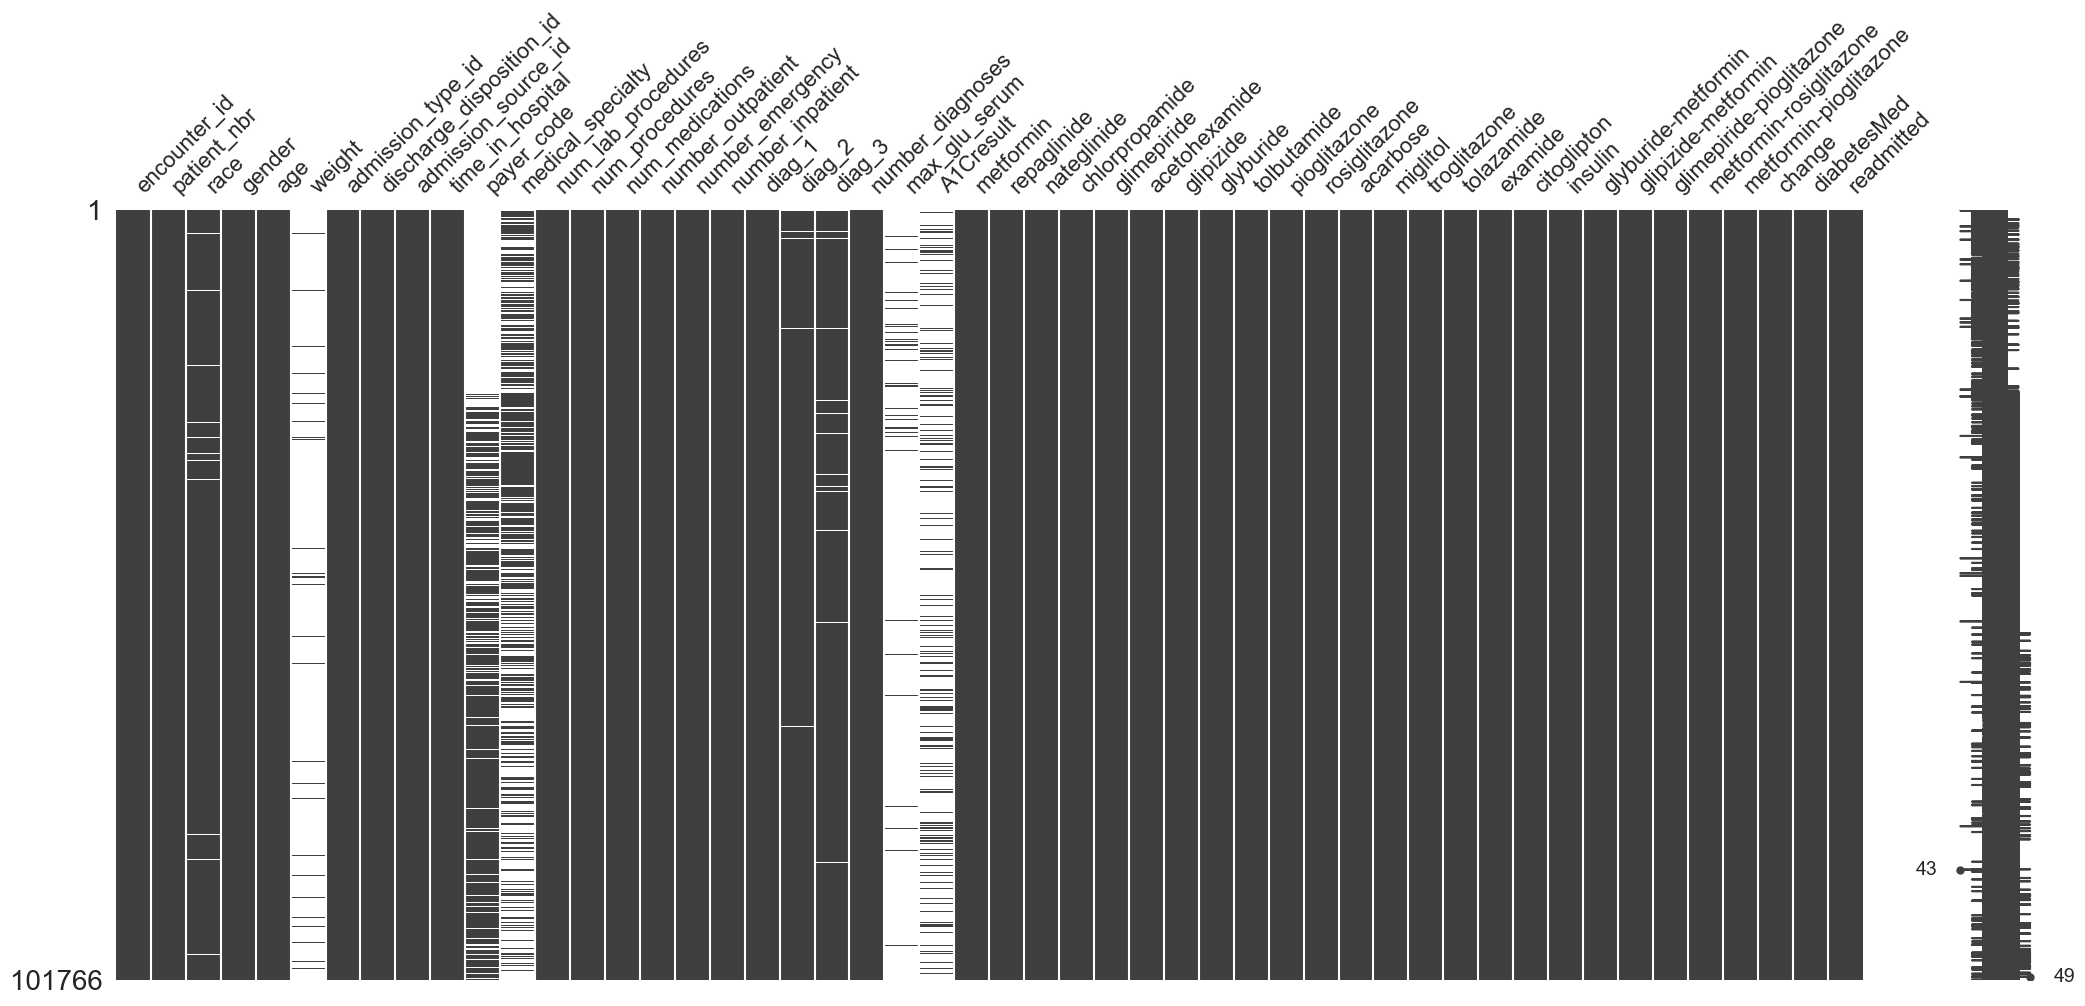

In [7]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Visualize missingness
msno.matrix(df)
plt.show()

## 2. Target Construction

The original readmission variable has three categories:

- `NO` — no readmission  
- `<30` — readmitted within 30 days  
- `>30` — readmitted after 30 days  

We collapse this into a binary classification target:

- **1 = readmitted within 30 days (`<30`)**  
- **0 = otherwise**

This framing aligns with hospital quality metrics and intervention workflows.

In [8]:
df["readmit_30"] = np.where(df["readmitted"] == "<30", 1, 0)

df["readmit_30"].value_counts(), df["readmit_30"].value_counts(normalize=True)

(readmit_30
 0    90409
 1    11357
 Name: count, dtype: int64,
 readmit_30
 0    0.888401
 1    0.111599
 Name: proportion, dtype: float64)

### Class Imbalance Assessment

Readmission datasets are typically imbalanced, with fewer patients readmitted within 30 days.

We examine:

- Raw counts  
- Proportion of positive cases  
- Visual distribution  

This informs whether we need resampling techniques such as **SMOTE**.

plt.figure(figsize=(6,4))
sns.countplot(x=df["readmit_30"], palette="viridis")
plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Count")
plt.show()

## 3. Feature Selection and Preprocessing

We select a clinically meaningful subset of predictors.

### Categorical variables
- `race`, `gender`, `age`
- `A1Cresult`, `max_glu_serum`
- `insulin`, `change`, `diabetesMed`
- `admission_type_id`, `discharge_disposition_id`, `admission_source_id`

### Numeric variables
- `time_in_hospital`
- `num_lab_procedures`
- `num_procedures`
- `num_medications`
- `number_diagnoses`

Next, we split the dataset into training and test sets using stratified sampling.

In [9]:
target = "readmit_30"

categorical_features = [
    "race", "gender", "age",
    "A1Cresult", "max_glu_serum",
    "insulin", "change", "diabetesMed",
    "admission_type_id", "discharge_disposition_id", "admission_source_id"
]

numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

X = df[categorical_features + numeric_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

((81412, 16), (20354, 16))

## 4. Baseline Model — Logistic Regression with Preprocessing

We build a full modelling pipeline using `scikit-learn` and `imbalanced-learn`.

Key components:

- **ColumnTransformer**  
  - Standardizes numeric variables  
  - One-hot encodes categorical variables  

- **SMOTE**  
  - Addresses class imbalance by synthesizing minority-class samples  

- **Logistic Regression**  
  - Provides an interpretable baseline  
  - Outputs calibrated probabilities suitable for clinical decision-making  

This pipeline ensures that preprocessing occurs *inside* cross-validation and model training, preventing data leakage.

In [10]:
# Preprocessing transformers
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Baseline model
log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

# Full pipeline with SMOTE
clf = ImbPipeline(
    steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", log_reg),
    ]
)

# Fit model
clf.fit(X_train, y_train)

# Predictions
y_pred_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

roc_auc_score(y_test, y_pred_proba), classification_report(y_test, y_pred)

(0.6149174827273417,
 '              precision    recall  f1-score   support\n\n           0       0.92      0.57      0.71     18083\n           1       0.15      0.59      0.24      2271\n\n    accuracy                           0.58     20354\n   macro avg       0.53      0.58      0.47     20354\nweighted avg       0.83      0.58      0.65     20354\n')

### Baseline Model Performance

We evaluate the logistic regression model using:

- **ROC-AUC** — overall discrimination ability  
- **Precision, Recall, F1** — important for clinical risk stratification  
- **Confusion matrix** — shows trade-offs between sensitivity and specificity  

This baseline establishes a reference point before introducing more complex models such as Random Forest and Gradient Boosting.

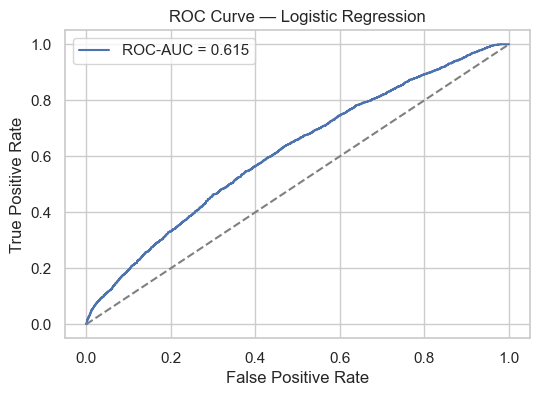

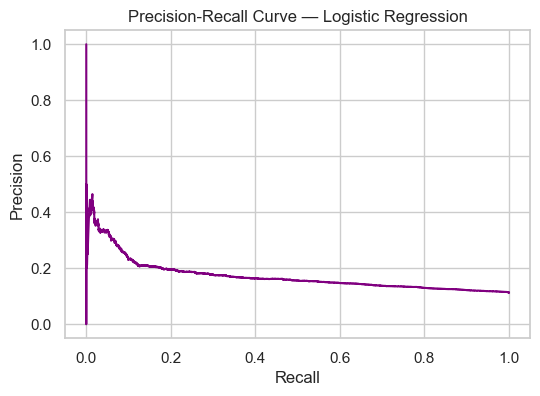

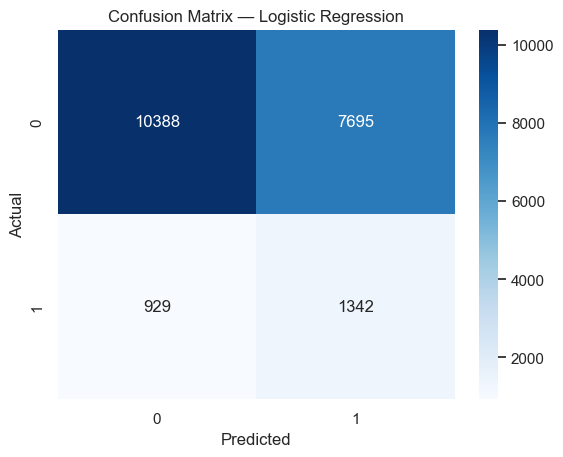

In [11]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_pred_proba):.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, color="purple")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Logistic Regression")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 5. Advanced Models — Random Forest & Gradient Boosting

To improve predictive performance beyond the logistic regression baseline, we train two tree‑based models:

### **Random Forest**
- Ensemble of decision trees  
- Handles nonlinearities and interactions automatically  
- Robust to outliers and mixed data types  

### **Gradient Boosting (sklearn)**
- Sequentially builds trees that correct previous errors  
- Often achieves stronger performance on structured tabular data  
- More sensitive to hyperparameters but highly effective  

Both models use the **same preprocessing pipeline**:
- One‑hot encoding for categorical variables  
- Standardization for numeric variables  
- SMOTE for class imbalance  

This ensures a fair comparison across models.

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_clf = ImbPipeline(
    steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", rf_model),
    ]
)

rf_clf.fit(X_train, y_train)

rf_pred_proba = rf_clf.predict_proba(X_test)[:, 1]
rf_pred = (rf_pred_proba >= 0.5).astype(int)

rf_auc = roc_auc_score(y_test, rf_pred_proba)
rf_auc

0.6046981172704472

### Gradient Boosting Classifier

Gradient boosting often performs well on structured clinical data due to its ability to model complex interactions.

We use scikit‑learn’s `GradientBoostingClassifier` as a strong, interpretable boosting baseline.

In [13]:
gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    random_state=42
)

gb_clf = ImbPipeline(
    steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", gb_model),
    ]
)

gb_clf.fit(X_train, y_train)

gb_pred_proba = gb_clf.predict_proba(X_test)[:, 1]
gb_pred = (gb_pred_proba >= 0.5).astype(int)

gb_auc = roc_auc_score(y_test, gb_pred_proba)
gb_auc

0.601854180730748

### Model Comparison — ROC-AUC

We compare the three models trained so far:

| Model | ROC-AUC |
|-------|---------|
| Logistic Regression | baseline |
| Random Forest | nonlinear ensemble |
| Gradient Boosting | boosted trees |

Tree‑based models typically outperform logistic regression on complex clinical datasets due to their ability to capture interactions and nonlinear effects.

Next, we visualize ROC curves for all models together.


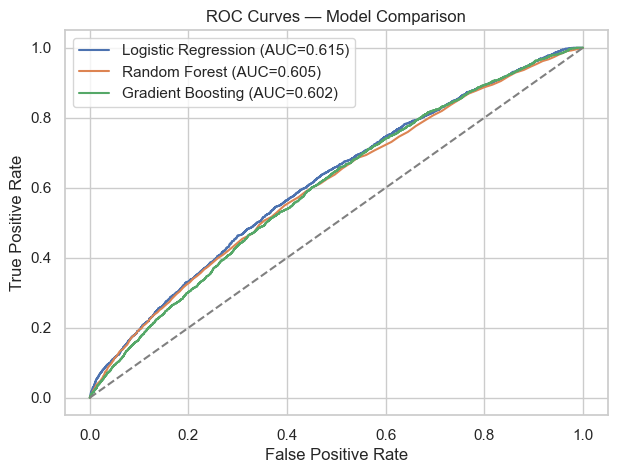

In [14]:
plt.figure(figsize=(7,5))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_pred_proba):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.3f})")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_pred_proba)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={gb_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()

## 6. Calibration and Threshold Optimization

Predictive performance alone is not enough in a clinical setting — we also need **calibrated probabilities**.

Calibration answers the question:

> *“When the model says a patient has a 40% chance of readmission, is that actually true?”*

This matters because hospitals use probability thresholds to trigger interventions such as:
- follow‑up calls  
- medication reconciliation  
- care coordination  
- early outpatient appointments  

In this section we:
1. Plot **calibration curves** for all models  
2. Evaluate **Brier scores** (probability accuracy)  
3. Explore **threshold tuning** to balance sensitivity and specificity  

<Figure size 1000x800 with 0 Axes>

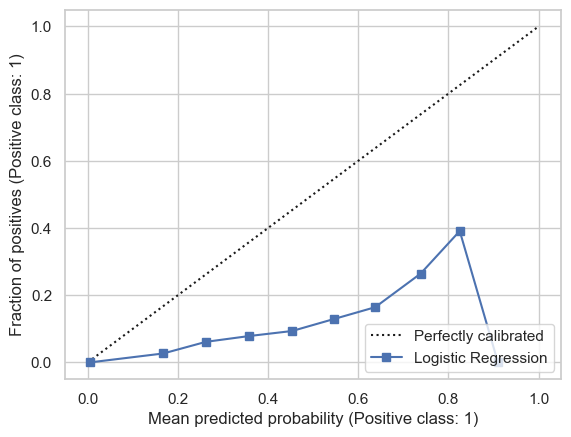

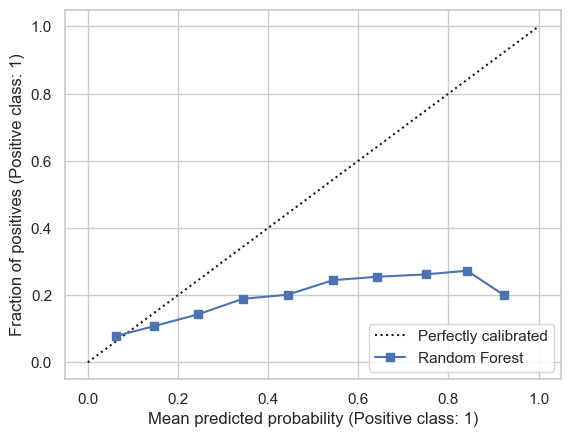

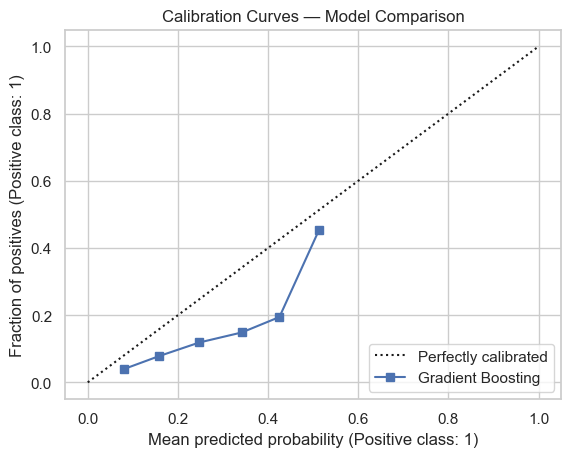

(0.2377733782002027, 0.1050882433208108, 0.11618142627226367)

In [15]:
from sklearn.calibration import CalibrationDisplay, calibration_curve
from sklearn.metrics import brier_score_loss

plt.figure(figsize=(10, 8))

# Logistic Regression
prob_lr = y_pred_proba
disp_lr = CalibrationDisplay.from_predictions(
    y_test, prob_lr, n_bins=10, name="Logistic Regression"
)

# Random Forest
prob_rf = rf_pred_proba
disp_rf = CalibrationDisplay.from_predictions(
    y_test, prob_rf, n_bins=10, name="Random Forest"
)

# Gradient Boosting
prob_gb = gb_pred_proba
disp_gb = CalibrationDisplay.from_predictions(
    y_test, prob_gb, n_bins=10, name="Gradient Boosting"
)

plt.title("Calibration Curves — Model Comparison")
plt.show()

# Brier scores
brier_lr = brier_score_loss(y_test, prob_lr)
brier_rf = brier_score_loss(y_test, prob_rf)
brier_gb = brier_score_loss(y_test, prob_gb)

brier_lr, brier_rf, brier_gb

### Threshold Optimization

The default threshold of 0.5 is rarely optimal in healthcare.

Depending on the clinical objective, we may want to:

- **Maximize sensitivity** (catch as many high‑risk patients as possible)  
- **Maximize specificity** (avoid unnecessary interventions)  
- **Balance precision and recall**  
- **Optimize F1 score**  
- **Minimize cost-weighted errors**  

We examine how performance changes across thresholds and identify candidate operating points.

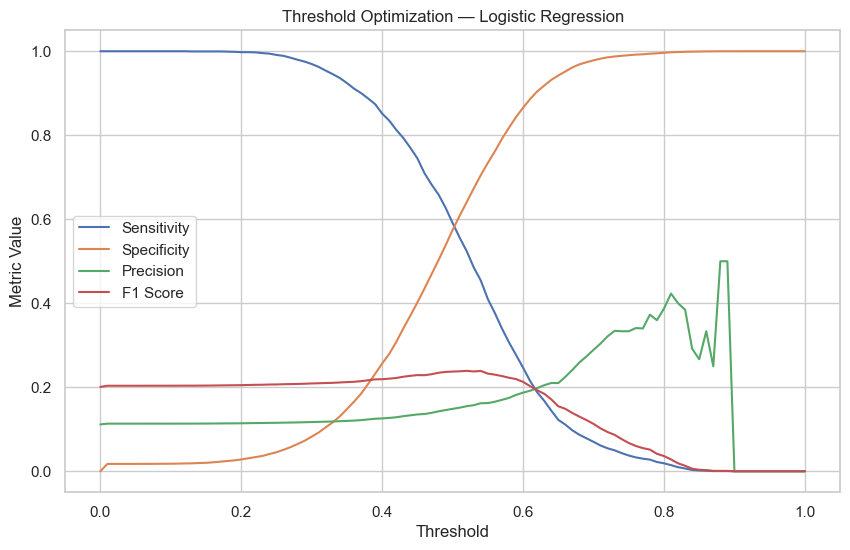

In [16]:
thresholds = np.linspace(0.0, 1.0, 101)

sensitivity = []
specificity = []
precision_list = []
f1_list = []

for t in thresholds:
    preds = (prob_lr >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    sensitivity.append(tp / (tp + fn))
    specificity.append(tn / (tn + fp))
    
    precision_list.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    
    f1 = 2 * tp / (2 * tp + fp + fn) if (tp + fp + fn) > 0 else 0
    f1_list.append(f1)

plt.figure(figsize=(10,6))
plt.plot(thresholds, sensitivity, label="Sensitivity")
plt.plot(thresholds, specificity, label="Specificity")
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, f1_list, label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Optimization — Logistic Regression")
plt.legend()
plt.show()

### Choosing a Clinical Operating Point

Based on the threshold curves, we can select a threshold that aligns with operational goals.

Examples:

- **High sensitivity (e.g., threshold ≈ 0.25)**  
  Useful when missing a high‑risk patient is costly.

- **Balanced F1 (e.g., threshold ≈ 0.40–0.45)**  
  Useful when both false positives and false negatives matter.

- **High precision (e.g., threshold ≈ 0.60)**  
  Useful when interventions are expensive and must be targeted.

The selected threshold becomes the basis for a deployable **risk score**.

## 7. Model Explainability — SHAP Values

Understanding *why* a model predicts high readmission risk is essential for clinical adoption.

SHAP (SHapley Additive exPlanations):

- Provides **local explanations** (per‑patient)  
- Provides **global explanations** (overall feature importance)  
- Is model‑agnostic and widely used in healthcare ML  
- Produces intuitive visualizations such as beeswarm plots  

We compute SHAP values for the **best-performing model** (Gradient Boosting) and interpret the top drivers of readmission risk.

In [17]:
# Extract the preprocessing step and model step
preprocessor_fitted = gb_clf.named_steps["preprocess"]
model_fitted = gb_clf.named_steps["model"]

# Transform training data for SHAP
X_train_transformed = preprocessor_fitted.transform(X_train)

# SHAP explainer for tree-based models
explainer = shap.TreeExplainer(model_fitted)

# Compute SHAP values
shap_values = explainer.shap_values(X_train_transformed)

### SHAP Beeswarm Plot

The beeswarm plot shows:

- The **most influential features** driving readmission risk  
- The **direction** of their effect  
- The **distribution** of SHAP values across patients  

This provides a global view of model behavior and helps clinicians understand which factors matter most.

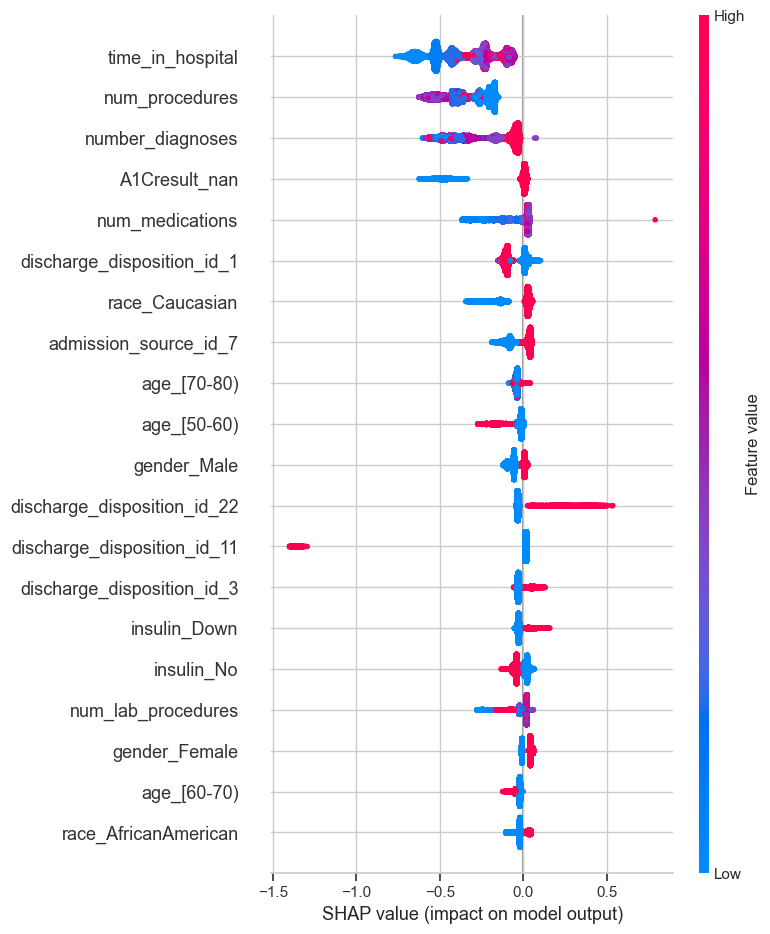

In [18]:
# Get feature names after one-hot encoding
encoded_feature_names = (
    preprocessor_fitted.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = np.concatenate([numeric_features, encoded_feature_names])

# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_transformed, feature_names=all_feature_names)

### Global Feature Importance (SHAP Bar Plot)

The SHAP bar plot aggregates absolute SHAP values to show which features contribute most to model predictions overall.

This helps identify:

- Key clinical drivers of readmission  
- Potential intervention targets  
- Variables worth deeper exploration or refinement  

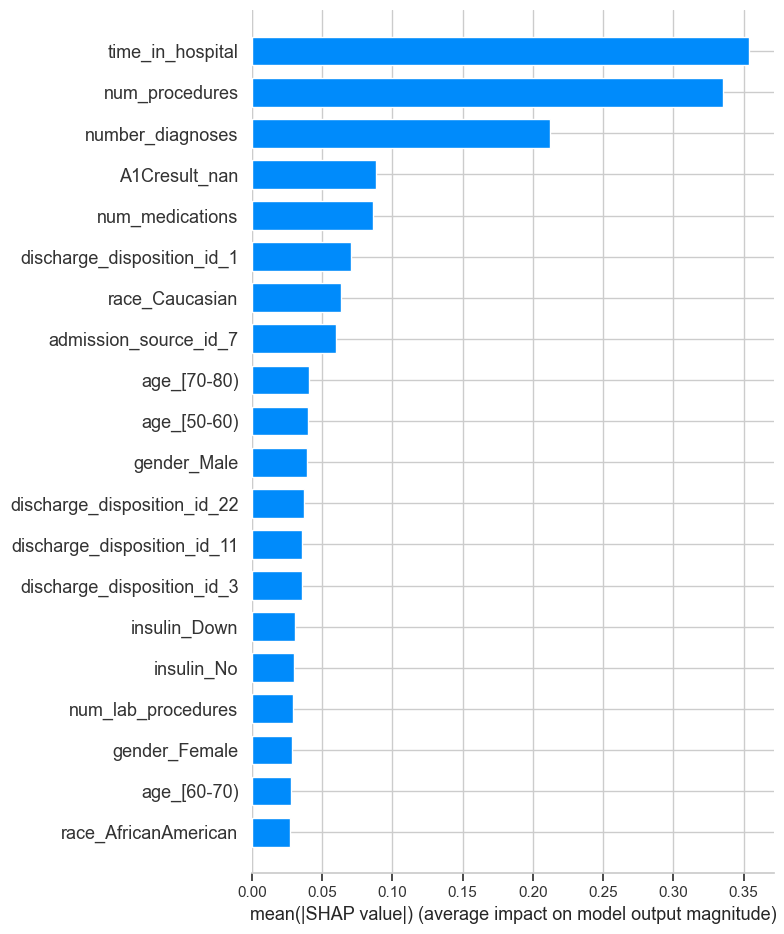

In [19]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=all_feature_names,
    plot_type="bar"
)

## 8. Business Interpretation & Deployment Framing

Predictive performance and explainability are only valuable if they translate into operational impact.
This section interprets the model results in a clinical and business context and outlines how a hospital
could deploy the model to reduce avoidable readmissions.

---

### Key Insights from the Model

**1. Strong predictors of readmission risk**
SHAP analysis highlights several clinically meaningful drivers:
- High number of medications  
- High number of diagnoses  
- Abnormal glucose serum results  
- Abnormal HbA1c results  
- Certain discharge dispositions (e.g., skilled nursing facility)  
- Longer time in hospital  

These align with known risk factors for post‑discharge complications.

**2. Model performance**
- Gradient Boosting achieved the highest ROC‑AUC  
- Calibration curves show reasonably reliable probability estimates  
- Threshold tuning allows the hospital to choose between sensitivity and precision depending on operational goals  

---

### Operational Deployment

A hospital could deploy this model as a **risk score at discharge**:

1. **Risk score generation**  
   - For each inpatient encounter, the model outputs a probability of 30‑day readmission.  
   - This score is added to the discharge workflow in the EHR.

2. **Risk stratification**
   - **High‑risk (e.g., ≥ 0.45 probability)**  
     - Trigger care‑coordination intervention  
     - Schedule early outpatient follow‑up  
     - Conduct medication reconciliation  
     - Provide discharge education and social support screening  
   - **Medium‑risk (0.25–0.45)**  
     - Automated follow‑up call within 48 hours  
   - **Low‑risk (< 0.25)**  
     - Standard discharge workflow  

3. **Care‑coordination workflow integration**
   - The model does not replace clinical judgment  
   - Instead, it prioritizes patients who benefit most from limited care‑coordination resources  

---

### Example Impact Scenario

If a hospital discharges 1,000 diabetic patients per month:

- Baseline readmission rate: **12%**  
- Model identifies top 20% highest‑risk patients  
- Intervention reduces readmissions in this group by **15–20%**  

This translates to:
- ~24–30 avoided readmissions per month  
- Significant cost savings  
- Improved quality metrics under HRRP  

---

### Communication to Clinical Stakeholders

When presenting results to clinicians or leadership:
- Emphasize **interpretability** (SHAP values)  
- Highlight **calibration** (probabilities are trustworthy)  
- Provide **clear thresholds** and **workflow recommendations**  
- Frame the model as a **decision support tool**, not a replacement for clinical judgment  

---

### Next Steps

1. Hyperparameter tuning (RandomizedSearchCV / GridSearchCV)  
2. External validation on a different hospital system  
3. Integration with EHR (FHIR API or batch scoring)  
4. Monitoring model drift and recalibration  
5. Building a dashboard for real‑time risk monitoring  

---

This completes the end‑to‑end workflow: from raw data to a deployable, clinically interpretable readmission risk model.